# Assignment 1: Data Preprocessing

**Dataset:** House Prices: Advanced Regression Techniques

**Goal:** Apply data retrieval, cleaning, exploratory data analysis, and feature engineering to prepare a processed dataset for regression modeling.









## 1. Import Libraries

We import the libraries needed for loading data cleaning visualization encoding and preprocessing pipelines.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.1 Data Retrieval




In [3]:
train = pd.read_csv("/content/drive/MyDrive/ML/Assignment01/data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/ML/Assignment01/data/test.csv")

print('Training data shape:', train.shape)
print('Testing data shape:', test.shape)

train.head()

Training data shape: (1460, 81)
Testing data shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print('Training data descriptive statistics:')
display(train.describe(include='all'))

Training data descriptive statistics:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


### 1.2 Dataset Inspection

Here, we check column names data types and memory usage. This helps us understand which columns are numerical and which are categorical.

In [5]:
print('Training dataset information:')
train.info()

print('\nTesting dataset information:')
test.info()

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 no

### 1.3 Memory Management

Some integer and float columns can be downcasted to smaller data types. Categorical string columns can also be converted to `category` type to reduce memory usage.

In [6]:
def optimize_memory(df):
    """Reduce memory usage by downcasting numeric columns and converting text columns to category."""
    df_optimized = df.copy()

    for col in df_optimized.columns:
        if df_optimized[col].dtype == 'int64':
            df_optimized[col] = pd.to_numeric(df_optimized[col], downcast='integer')
        elif df_optimized[col].dtype == 'float64':
            df_optimized[col] = pd.to_numeric(df_optimized[col], downcast='float')
        elif df_optimized[col].dtype == 'object':
            df_optimized[col] = df_optimized[col].astype('category')

    return df_optimized

before_memory = train.memory_usage(deep=True).sum() / 1024**2
train_optimized = optimize_memory(train)
after_memory = train_optimized.memory_usage(deep=True).sum() / 1024**2

print(f'Memory before optimization: {before_memory:.2f} MB')
print(f'Memory after optimization:  {after_memory:.2f} MB')
print(f'Memory reduction: {before_memory - after_memory:.2f} MB')

train_optimized.dtypes.head(15)

Memory before optimization: 3.43 MB
Memory after optimization:  0.18 MB
Memory reduction: 3.25 MB


,0
Id,int16
MSSubClass,int16
MSZoning,category
LotFrontage,float32
LotArea,int32
Street,category
Alley,category
LotShape,category
LandContour,category
Utilities,category


## 2. Data Cleaning

This section handles missing values and outliers and target transformation.

### 2.1 Missing Value Analysis

First we identify columns with missing values. Some missing values in this dataset do not mean data entry errors. For example `NaN` in `PoolQC` usually means the house has no pool and `NaN` in `Alley` usually means there is no alley access.

In [7]:
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Missing Percentage': missing_percent
}).sort_values(by='Missing Percentage', ascending=False)

missing_table[missing_table['Missing Values'] > 0]

,Missing Values,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


### 2.2 Handling Special Missing Categories

For columns such as `PoolQC`, `MiscFeature`, `Alley`, and `Fence`, missing values represent a meaningful category, not simply unknown information. Therefore, we replace them with labels such as `No Pool`, `No Misc Feature`, `No Alley Access`, and `No Fence`. The median on the other hand represents the middle value of the data making it a more stable choice for imputation when outliers might be present in the numerical features.

In [8]:
train_clean = train.copy()
test_clean = test.copy()

special_missing_values = {
    'PoolQC': 'No Pool',
    'MiscFeature': 'No Misc Feature',
    'Alley': 'No Alley Access',
    'Fence': 'No Fence',
    'FireplaceQu': 'No Fireplace',
    'GarageType': 'No Garage',
    'GarageFinish': 'No Garage',
    'GarageQual': 'No Garage',
    'GarageCond': 'No Garage',
    'BsmtQual': 'No Basement',
    'BsmtCond': 'No Basement',
    'BsmtExposure': 'No Basement',
    'BsmtFinType1': 'No Basement',
    'BsmtFinType2': 'No Basement',
    'MasVnrType': 'None'
}

# 1. Fill special missing values (categorical NaNs)
# fillna with a dictionary will only fill values in matching columns and ignore others.
train_clean = train_clean.fillna(special_missing_values)
test_clean = test_clean.fillna(special_missing_values)

# 2. Fill numerical missing values using median
# Calculate medians from training data for relevant numerical columns
numeric_cols = train_clean.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice', errors='ignore')
median_fill_values = train_clean[numeric_cols].median()

# Apply medians to both train_clean and test_clean.

train_clean = train_clean.fillna(median_fill_values)
test_clean = test_clean.fillna(median_fill_values)

# 3. Fill remaining categorical missing values using mode from training data

categorical_cols = train_clean.select_dtypes(include=['object', 'category']).columns
mode_fill_values = {col: train_clean[col].mode()[0] for col in categorical_cols}

# Apply modes to both train_clean and test_clean.

train_clean = train_clean.fillna(mode_fill_values)
test_clean = test_clean.fillna(mode_fill_values)

print('Remaining missing values in train:', train_clean.isnull().sum().sum())
print('Remaining missing values in test:', test_clean.isnull().sum().sum())

Remaining missing values in train: 0
Remaining missing values in test: 0


### 2.3 Outlier Analysis

We inspect the distribution of `SalePrice` and the relationship between `GrLivArea` and `SalePrice`. Very large houses with unusually low prices can negatively affect regression model training, so they may be removed.

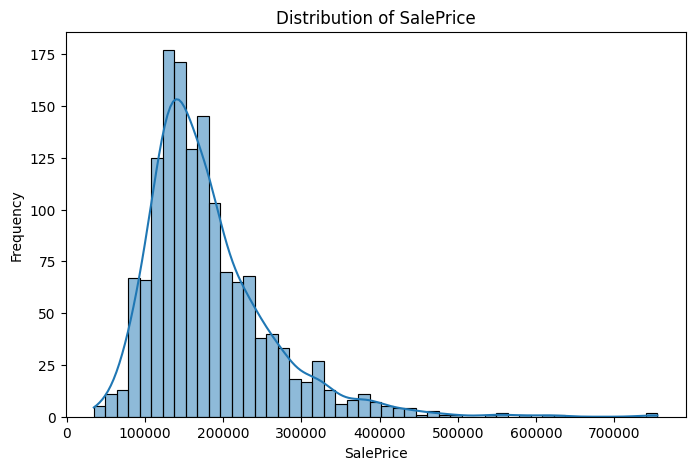

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(train_clean['SalePrice'], kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

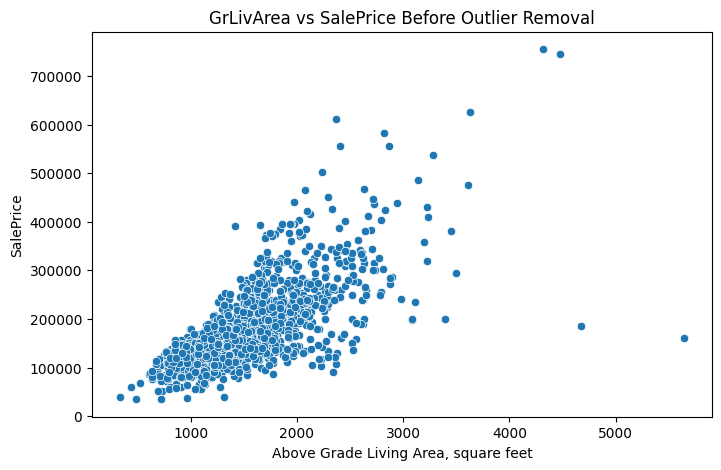

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=train_clean, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice Before Outlier Removal')
plt.xlabel('Above Grade Living Area, square feet')
plt.ylabel('SalePrice')
plt.show()

Based on the common House Prices dataset pattern, homes with `GrLivArea` greater than 4000 square feet and relatively low `SalePrice` behave as strong outliers. Removing them can help the regression model learn the main trend more accurately.

In [11]:
outlier_condition = (train_clean['GrLivArea'] > 4000) & (train_clean['SalePrice'] < 300000)
outliers = train_clean[outlier_condition]

print('Number of outliers identified:', outliers.shape[0])
outliers[['Id', 'GrLivArea', 'SalePrice']]

Number of outliers identified: 2


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [12]:
train_clean = train_clean[~outlier_condition].reset_index(drop=True)

print('Training data shape after outlier removal:', train_clean.shape)

Training data shape after outlier removal: (1458, 81)


### 2.4 Target Transformation

The `SalePrice` distribution is right-skewed. We apply `np.log1p` to reduce skewness and make the target variable more suitable for regression modeling.

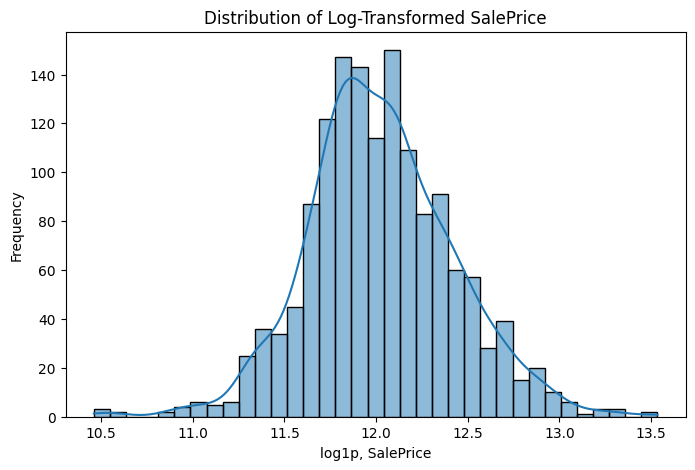

In [13]:
train_clean['SalePrice_Log'] = np.log1p(train_clean['SalePrice'])

plt.figure(figsize=(8, 5))
sns.histplot(train_clean['SalePrice_Log'], kde=True)
plt.title('Distribution of Log-Transformed SalePrice')
plt.xlabel('log1p, SalePrice')
plt.ylabel('Frequency')
plt.show()

## 3. Exploratory Data Analysis, EDA

This section explores relationships between features and the target variable.

### 3.1 Correlation Analysis

We calculate correlations between numeric features and `SalePrice`, then identify the top 5 strongest numerical predictors.

In [14]:
numeric_train = train_clean.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_train.corr()

saleprice_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)
top_5_features = saleprice_corr.drop(['SalePrice', 'SalePrice_Log'], errors='ignore').head(5)

print('Top 5 numerical features correlated with SalePrice:')
print(top_5_features)

Top 5 numerical features correlated with SalePrice:
OverallQual    0.795774
GrLivArea      0.734968
TotalBsmtSF    0.651153
GarageCars     0.641047
1stFlrSF       0.631530
Name: SalePrice, dtype: float64


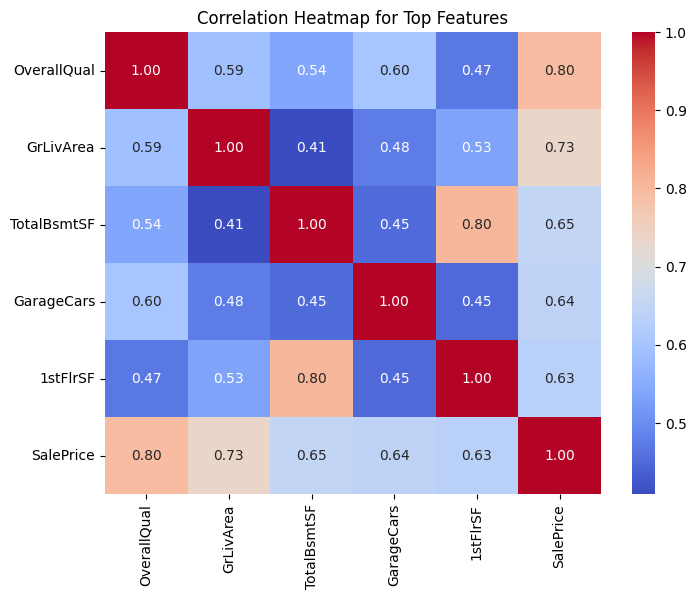

In [15]:
top_features_for_heatmap = list(top_5_features.index) + ['SalePrice']

plt.figure(figsize=(8, 6))
sns.heatmap(train_clean[top_features_for_heatmap].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Top Features')
plt.show()

### 3.2 Visual Exploration: GrLivArea and SalePrice

This scatter plot shows the relationship between living area and house price. The color represents `OverallQual`, which helps us see how overall quality affects price.

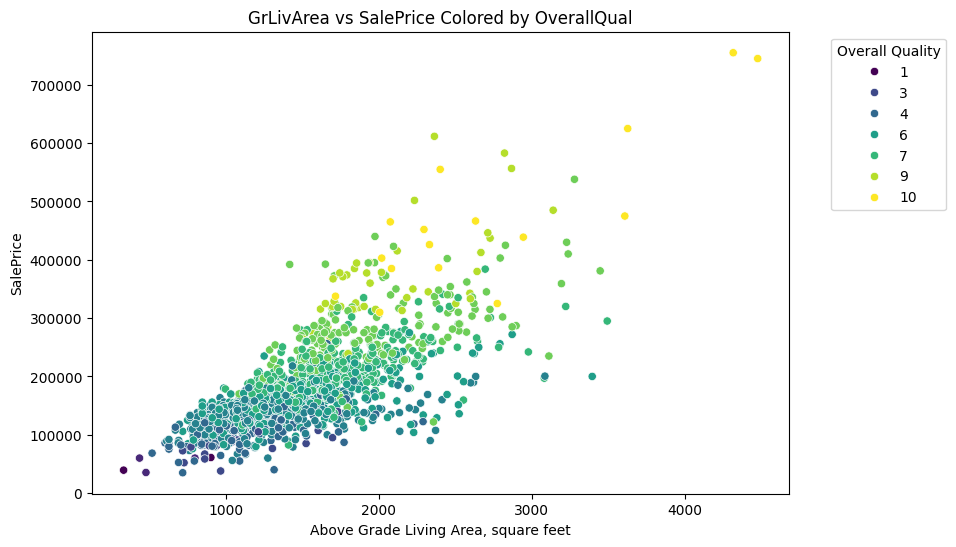

In [16]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=train_clean,
    x='GrLivArea',
    y='SalePrice',
    hue='OverallQual',
    palette='viridis'
)
plt.title('GrLivArea vs SalePrice Colored by OverallQual')
plt.xlabel('Above Grade Living Area, square feet')
plt.ylabel('SalePrice')
plt.legend(title='Overall Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### 3.3 Geographical Insights by Neighborhood

We compare the average sale price across neighborhoods to understand location-based price differences.

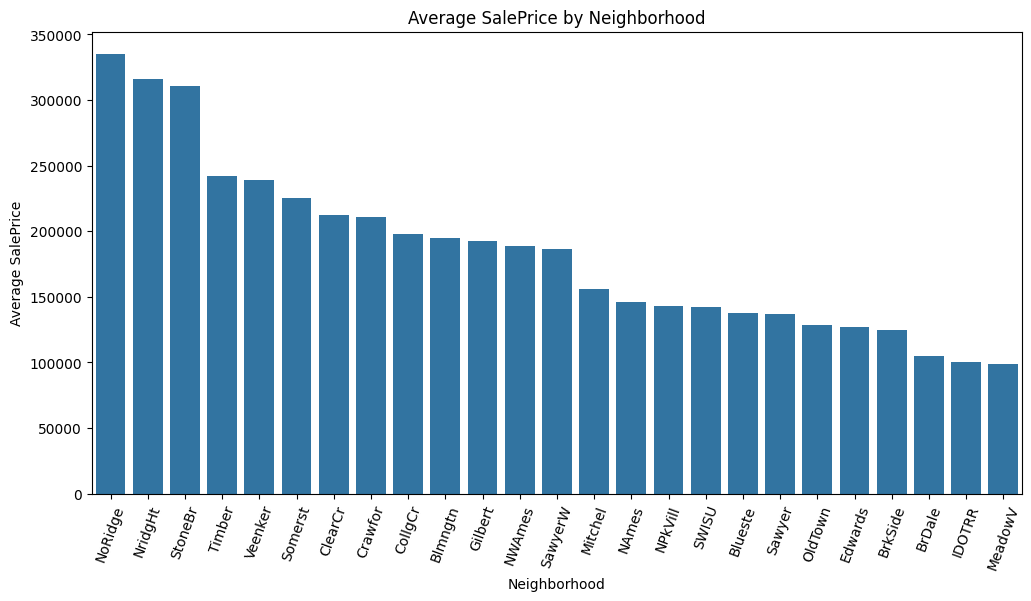

,Neighborhood,SalePrice
0,NoRidge,335295.317073
1,NridgHt,316270.623377
2,StoneBr,310499.000000
3,Timber,242247.447368
4,Veenker,238772.727273
5,Somerst,225379.837209
6,ClearCr,212565.428571
7,Crawfor,210624.725490
8,CollgCr,197965.773333
9,Blmngtn,194870.882353


In [17]:
neighborhood_prices = (
    train_clean.groupby('Neighborhood')['SalePrice']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(data=neighborhood_prices, x='Neighborhood', y='SalePrice')
plt.title('Average SalePrice by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average SalePrice')
plt.xticks(rotation=70)
plt.show()

neighborhood_prices.head(10)

## 4. Feature Engineering

Feature engineering creates useful new variables and converts categorical variables into model-friendly numeric form.

### 4.1 Create TotalSF

`TotalSF` combines basement area first floor area, and second floor area. This gives a stronger measurement of total usable house size.

In [18]:
def add_total_sf(df):
    df = df.copy()
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    return df

train_clean = add_total_sf(train_clean)
test_clean = add_total_sf(test_clean)

train_clean[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSF']].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


### 4.2 Feature Engineering

Feature engineering creates useful new variables and converts categorical variables into model-friendly numeric form.
4.1 Create TotalSF

`TotalSF` combines basement area first floor area, and second floor area. This gives a stronger measurement of total usable house size.4.2 Encoding Categorical Variables

Ordinal features have a clear ranking, so labelstyle ordinal encoding is appropriate. Nominal features do not have ranking, so onehot encoding is more suitable.

In [19]:
quality_order = ['No Basement', 'No Fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

ordinal_features = [
    'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual',
    'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond'
]

ordinal_features = [col for col in ordinal_features if col in train_clean.columns]

nominal_features = ['Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd']
nominal_features = [col for col in nominal_features if col in train_clean.columns]

print('Ordinal features:', ordinal_features)
print('Nominal features:', nominal_features)

Ordinal features: ['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'BsmtQual', 'BsmtCond', 'FireplaceQu', 'GarageQual', 'GarageCond']
Nominal features: ['Neighborhood', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd']


## 4.3 Reusable Preprocessing Pipeline

The pipeline applies the same preprocessing logic to both training and testing sets. This prevents inconsistent transformations.

In [20]:
def prepare_house_data(train_df, test_df):
    """Clean, engineer, and transform train and test datasets consistently."""
    train_processed = train_df.copy()
    test_processed = test_df.copy()

    # Remove strong outliers from training only
    outlier_condition = (train_processed['GrLivArea'] > 4000) & (train_processed['SalePrice'] < 300000)
    train_processed = train_processed[~outlier_condition].reset_index(drop=True)

    # Separate target
    y = np.log1p(train_processed['SalePrice'])
    X = train_processed.drop(['SalePrice'], axis=1)
    X_test = test_processed.copy()

    # Add engineered feature
    X = add_total_sf(X)
    X_test = add_total_sf(X_test)

    # Handle meaningful missing categorical values
    X = X.fillna(special_missing_values)
    X_test = X_test.fillna(special_missing_values)

    # Identify column types
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object']).columns.tolist()

    ordinal_features_available = [col for col in ordinal_features if col in categorical_features]
    nominal_features_available = [col for col in categorical_features if col not in ordinal_features_available]

    # Create ordinal category list for each ordinal feature
    ordinal_categories = [quality_order] * len(ordinal_features_available)

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

    ordinal_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])

    nominal_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('ord', ordinal_transformer, ordinal_features_available),
            ('nom', nominal_transformer, nominal_features_available)
        ],
        remainder='drop'
    )

    X_processed = preprocessor.fit_transform(X)
    X_test_processed = preprocessor.transform(X_test)

    # Get output feature names
    feature_names = []
    feature_names.extend(numeric_features)
    feature_names.extend(ordinal_features_available)

    if nominal_features_available:
        ohe = preprocessor.named_transformers_['nom'].named_steps['encoder']
        feature_names.extend(ohe.get_feature_names_out(nominal_features_available).tolist())

    X_processed_df = pd.DataFrame(X_processed, columns=feature_names)
    X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

    return X_processed_df, X_test_processed_df, y, preprocessor

X_processed, X_test_processed, y_log, preprocessing_pipeline = prepare_house_data(train, test)

print('Processed training shape:', X_processed.shape)
print('Processed testing shape:', X_test_processed.shape)
print('Target shape:', y_log.shape)

X_processed.head()

Processed training shape: (1458, 266)
Processed testing shape: (1459, 266)
Target shape: (1458,)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1.0,60.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,20.0,80.0,9600.0,6.0,8.0,1976.0,1976.0,0.0,978.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,3.0,60.0,68.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4.0,70.0,60.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5.0,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
